# Exploring the Australian Radio Talkback (ART) RO-Crate

This notebook uses `crategraph` to explore an RO-Crate of Australian Radio Talkback transcripts.
The focus is on identifying the people and places in the collection, what they actually said, and
what NLP `crategraph` makes possible itself, as well as what it can hand off to other tools.

## What you'll learn

- How to load a collection and get a feel for who and what is in it.
- How to filter and profile the people and recordings it contains.
- How to build and visualise a network of who spoke where.
- How to search the transcripts in plain language using crategraph's built-in semantic search.
- How to hand the text off to NLP tools (sentiment, named entities, topics) for deeper analysis.

## Running this tutorial

This notebook hands off to third-party NLP tools in Sections 8 to 10, so it needs a few extra
packages alongside `crategraph`. Launch from the repository root with `uv run`:

```bash
uv run --all-extras --with jupyter,pandas,plotly,transformers,torch,spacy jupyter notebook
```

Then download the small spaCy English model once, in an environment that includes spaCy:

```bash
uv run --all-extras --with spacy python -m spacy download en_core_web_sm
```

## 1. Load the crate

In [ ]:
from crategraph import Crate
import pandas as pd
import plotly.express as px
import re
from pathlib import Path
from collections import Counter, defaultdict

crate = Crate("./data/talkback")
crate

In [ ]:
crate.summary()

452 entities and 918 relationships. The crate is dominated by `Person` (323) and `File` (89) entities, with 29 `RepositoryObject` entities representing the actual radio recordings. The most common relationship is `ldac:speaker` (450 links), which connects people to the recordings they
spoke in.

## 2. Collection-level metadata

Check the non-`Person`/`File`/`RepositoryObject` entities to understand what
this collection actually is, who published it, and under what licence.


In [ ]:
metadata = crate.exclude(entity_types=["Person", "File", "RepositoryObject"])

for e in metadata.entities:
    print(e.id, e.types)
    for k, v in e.properties.items():
        print(" ", k, ":", str(v)[:200])
    print()

This is the "Australian Radio Talkback" (ART) corpus, a linguistics RO-Crate (LDaC Collection profile) archived by Macquarie University, with a DOI-based collection identifier (`doi:10.25949/24769434.v1`). It was generated from `ART-corpus-catalogue.xls` using the [`corpus-tools-australian-radio-talkback`](https://github.com/Language-Research-Technology/corpus-tools-australian-radio-talkback) tool. The licence entity is visible in the metadata above; the tutorials index centralises the dataset licence list.


## 3. The recordings (`RepositoryObject`)

Each `RepositoryObject` is a single radio talkback segment, with its station,
program, recording/transcription dates, subject, language, and links to its
transcript files and speakers.

In [ ]:
recordings_graph = crate.select(entity_types=["RepositoryObject"])
recordings = recordings_graph.entities

# count each recording's speakers, then pull the columns we want as rows
with_speaker_counts = recordings_graph.annotate_entities(
    speakers=lambda e: len(e.get("ldac:speaker") or [])
)
rows = with_speaker_counts.entity_records(
    columns=["name", "station", "program", "subject", "speakers"]
)
recordings_df = pd.DataFrame(rows).rename(columns={"name": "id"})

print(len(recordings_df), "recordings")
recordings_df

29 recordings spanning 10 stations, from national programs like *Australia Talks Back* (ABC National) down to local commercial shows like *Gardening
Talkback*. Each links out to a `-raw.txt`, `-plain.txt`, and `.csv` transcript file via `hasPart`, and to its speakers via `ldac:speaker`. Speaker counts range from a handful up to several dozen callers per episode. Notice that the subject column is a bit hit and miss.

## 4. Identifying the people

Select all `Person` entities and split them into the role-tagged speakers
(id pattern `.../person/<Role>#<Name>`) versus any other person entities
(e.g. catalogue contributors, who aren't linked via `ldac:speaker`).

In [ ]:
people = crate.select(entity_types=["Person"]).annotate_entities(
    role_tagged=lambda e: "/person/" in e.id
)
speakers = people.where(role_tagged=True)

print("Total people:", len(people))
print("Role-tagged speakers:", len(speakers))

# the rest are catalogue contributors, not linked via ldac:speaker
people.where(role_tagged=False).entity_records(columns=["name"])

### Speaker demographics

Each role-tagged speaker carries `role`, `sex`, `ldac:age`, and (sometimes)
`location` properties. Tally them to profile the cast of speakers.

In [ ]:
def clean_sex(value):
    value = (value or "").strip().upper()
    return value if value in ("F", "M") else "?"


def clean_age_band(value):
    value = (value or "").strip().rstrip("?")
    if value in ("<45",):
        return "<45"
    if value in (">45", ">65", ">70"):
        return ">45"
    try:
        return "<45" if float(value) < 45 else ">45"
    except ValueError:
        return "?"


# annotate the cleaned demographic fields, then let entity_counts tally each
profiled = speakers.annotate_entities(
    sex_clean=lambda e: clean_sex(e.get("sex")),
    age_band=lambda e: clean_age_band(e.get("ldac:age")),
    location_clean=lambda e: e.get("location") or "?",
)

print("Role:", profiled.entity_counts("role"))
print("Sex:", profiled.entity_counts("sex_clean"))
print("Age band:", profiled.entity_counts("age_band"))
print("Top locations:", profiled.entity_counts("location_clean")[:10])

The aggregate sex split (above) looks roughly even. But that number averages over three very different roles (Caller, Expert and Presenter).

In [ ]:
speakers_df = pd.DataFrame(
    profiled.entity_records(columns=["role", "sex_clean", "age_band"])
).rename(columns={"sex_clean": "sex"})

role_sex = pd.crosstab(speakers_df["role"], speakers_df["sex"])
role_sex["% male"] = (
    100 * role_sex.get("M", 0) / (role_sex.get("M", 0) + role_sex.get("F", 0))
).round(1)
role_sex

In [ ]:
pd.crosstab(speakers_df["role"], speakers_df["age_band"])

The aggregate sex split (162F/155M) hides a real skew once you split by role:

- Experts are 72% male (26M/10F) and Presenters are 62% male (16M/10F)
- Callers are slightly majority-female (142F/113M, 44% male)

Anyone can call in, but the "authority" roles (the people running the show and the people brought on as experts) skew male. The aggregate number, by averaging over all three roles, hides this.

Age bands are coarse (`<45`/`>45`, mostly inferred rather than exact) and locations are mostly unspecified (149 of 322 unknown); where known, Sydney (13) and Melbourne (8) dominate. 

## 5. The people to recordings network and what it reveals about the IDs

Select the `Person` entities, then `expand()` one hop outward along the `ldac:speaker` relationship to pull in the recordings each person spoke in. This produces a bipartite-ish network of people and recordings and the network's structure turns out to expose a data-quality problem in how Caller identities were minted.

In [ ]:
people_network = crate.select(entity_types=["Person"]).expand(
    depth=1, via="ldac:speaker"
)
people_network

In [ ]:
people_network.visualise(
    colour_by="community",
    size_by="connections",
    simple=True,
    filepath="talkback-people.html",
)

Creates a 352-entity, 450-relationship network saved to `talkback-people.html` (open with
`!open "talkback-people.html"`). Colouring by `community` (Louvain) groups each recording with the
people who spoke in it, and `size_by="connections"` makes the busiest nodes pop.

The largest nodes overall are recordings, because some episodes have many speakers. Among the
person nodes, the busiest Caller names are probably not single frequent callers: Caller IDs here
are first-name-only, so a node like `Caller#Paul` can merge several real people who share a first
name.


## 6. Native semantic search over the transcripts

Everything so far has only looked at structured metadata: names, roles, counts. `crategraph` can
also build an embedding-backed search index directly over the transcript content and let you query
it in plain language. Restrict to the clean `-plain.txt` transcripts first (same
`annotate_entities()` + `where()` idiom as filtering by any other derived property), then build the
index.

In [ ]:
text_files = crate.select(entity_types=["File"])
plain_text = text_files.annotate_entities(
    is_plain=lambda e: e.id.endswith("-plain.txt")
).where(is_plain=True)

index_path = "talkback-index.db"
stats = plain_text.build_semantic_index(index_path, progress=False)
stats

Query in plain language, grounded in real recorded subjects so the results are checkable against Section 3's table. A hit on "Cloudstreet Tim Winton" should surface `Nat2`, whose `subject` is literally "Cloudstreet: Tim Winton". Each result is a `File` entity; expand backward via `hasPart` to recover the owning recording's station/program/subject.

In [ ]:
queries = [
    "Tim Winton",
    "therapy",
    "asylum seekers and refugees",
    "religion and politics",
]

for query in queries:
    hits = crate.search(query, mode="semantic", store_path=index_path, k=2)
    owners = hits.expand(depth=1, via="hasPart").select(entity_types=["RepositoryObject"])
    print(f"## {query!r}")
    for owner in owners.entities:
        print(" ", owner.properties.get("name"), "-", owner.properties.get("station"), "|", owner.properties.get("subject"))
    print()

For RAG-style use, `chunk_records()` gives ranked, scored passages instead of
whole-file hits.

In [ ]:
for record in crate.chunk_records("asylum seekers and refugees", k=3, store_path=index_path):
    print(f"score={record['score']:.3f} {record['entity_id']}")
    print(" ", record["text"][:200].replace("\n", " "), "...")
    print()

Semantic search finds topically relevant recordings without any keyword match. The embeddings capture meaning, not just shared vocabulary. This is the piece that's native to `crategraph`: build once, then query the corpus in plain language.

## 7. Joining per-utterance speech to speaker demographics

Section 4 profiled speakers from their RO-Crate properties alone. To analyse what they actually said, join their per-utterance speech (from each recording's `.csv`, columns `Person,Speech,events`) to those same `role`/`sex` properties. The `Person` codes in each CSV (`P1`, `C1`, `E1`...) are locally scoped to that recording. `C1` means a different real person in `Nat1` than in `Nat4`. So the join must be done per-recording, using that recording's own `ldac:speaker` list and each speaker's `identifier` property to build the local code to Person map, rather than a single global lookup table.

In [ ]:
base_dir = Path(crate.source)
leaked_speaker_tag = re.compile(r"^\[[^\]]+\]\s*")

example_recording = recordings[0]
example_csv = next(
    (part for part in example_recording.properties.get("hasPart") or [] if part.endswith(".csv")),
    None,
)

print(example_recording.properties.get("name"), example_csv)
example_speakers = crate.entity_view(example_recording.id).related("ldac:speaker")
list(example_speakers)[:3]


For each recording, the transcript CSV uses local speaker codes such as `P1`, `C1`, and `E1`. Build that mapping for one recording first, so the larger join below is easier to read.


In [ ]:
example_local_speakers = {
    speaker.get("identifier"): speaker
    for speaker in example_speakers
}

{code: speaker.label for code, speaker in list(example_local_speakers.items())[:8]}


Now apply the same per-recording mapping across the whole crate. The loop keeps one row per spoken utterance and attaches the speaker's role and cleaned sex value from the RO-Crate metadata.


In [ ]:
utterance_rows = []

for recording in recordings:
    csv_name = next(
        (part for part in recording.properties.get("hasPart") or [] if part.endswith(".csv")),
        None,
    )
    if csv_name is None:
        continue

    speakers_for_recording = crate.entity_view(recording.id).related("ldac:speaker")
    local_speakers = {
        speaker.get("identifier"): speaker
        for speaker in speakers_for_recording
    }

    transcript_rows = pd.read_csv(base_dir / csv_name)
    for _, transcript_row in transcript_rows.iterrows():
        speaker = local_speakers.get(transcript_row["Person"])
        speech = transcript_row["Speech"]
        if speaker is None or pd.isna(speech):
            continue

        utterance_rows.append(
            {
                "recording": recording.properties.get("name"),
                "speaker_id": speaker.id,
                "role": speaker.get("role"),
                "sex": clean_sex(speaker.get("sex")),
                "text": leaked_speaker_tag.sub("", str(speech)),
            }
        )

utterances_df = pd.DataFrame(utterance_rows)
print(
    len(utterances_df),
    "utterances joined across",
    utterances_df["recording"].nunique(),
    "recordings",
)
utterances_df.head()


## 8. Transformer sentiment by role and sex

Section 4 found a structural skew: experts and presenters are disproportionately male. Does that
skew show up in how people talk? This section runs a Hugging Face transformer sentiment model over
every utterance, then aggregates by `role` and `sex`.

In [ ]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english"
)

utterance_texts = utterances_df["text"].tolist()
sentiment_results = sentiment_pipeline(utterance_texts, truncation=True, batch_size=32)
utterances_df["sentiment"] = [
    (1 if result["label"] == "POSITIVE" else -1) * result["score"]
    for result in sentiment_results
]

sentiment_by_role_sex = utterances_df.groupby(["role", "sex"])["sentiment"].agg(
    ["mean", "count"]
)
sentiment_by_role_sex.round(3)


Within every role, women read more positively than men in this model's scores.

Male Experts are the only subgroup with a net-negative average sentiment i.e. the group that's also 72% male reads the most negative on average. This is model-derived sentiment over short utterances, not ground truth about the speakers. It is best read as a prompt for closer qualitative checking, and it is consistent with male experts being brought on more often for clinical or contentious subjects such as health, terrorism, and policy.


Sentiment also varies by program, not just role/sex. There each utterance's `recording` is mapped to its `program` (from the `recordings` list in Section 3) and the average is charted.

In [ ]:
program_by_recording = {r.properties.get("name"): r.properties.get("program") for r in recordings}
utterances_df["program"] = utterances_df["recording"].map(program_by_recording)

program_sentiment = (
    utterances_df.groupby("program")["sentiment"].mean().sort_values().reset_index()
)

fig = px.bar(
    program_sentiment,
    x="sentiment",
    y="program",
    orientation="h",
    title="Average sentiment by program",
    color="sentiment",
    color_continuous_scale="RdYlGn",
    color_continuous_midpoint=0,
)
fig.update_layout(height=800)
fig.show()

The most negative programs are personality-driven current-affairs shows, e.g. *Neil Mitchell* (-0.257), while the most positive are lighter entertainment formats e.g. *Sharina's Psychic Encounters* (0.462) and *Love Song Dedications* (0.461). Format seems to predict tone.

## 9. spaCy NER on what's actually discussed

Everyone profiled so far is speaking in the corpus: Presenters, Callers, Experts. Below,
named-entity recognition is run over the `-plain.txt` transcripts to surface who and what is talked
about (politicians, places, organisations), which the graph's structured metadata doesn't fully
capture.

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm", disable=["parser", "tagger", "lemmatizer", "attribute_ruler"])
disfluencies = {
    "y'know", "mm", "um", "uh", "yeah", "okay", "lotta", "gonna", "gotta", "wanna", "kinda",
}

mentions = Counter()
locations_by_recording = defaultdict(Counter)
for record in plain_text.text_records():
    doc = nlp(record["text"])
    for ent in doc.ents:
        if ent.label_ not in ("PERSON", "GPE", "ORG") or ent.text.lower() in disfluencies:
            continue
        mentions[(ent.label_, ent.text)] += 1
        if ent.label_ == "GPE":
            locations_by_recording[record["entity_id"]][ent.text] += 1

places = [(text, n) for (label, text), n in mentions.most_common() if label == "GPE"]
people = [(text, n) for (label, text), n in mentions.most_common() if label == "PERSON"]

print("Top places discussed:", places[:10])
print()
print("Top names mentioned:", people[:10])

`GPE` (place) mentions are the cleanest signal. Australia, Sydney, Melbourne, and Queensland dominate, with Iraq, England, and Chechnya also
surfacing from the international/security topics covered in 2004. `PERSON` mentions are noisier. NER can't tell "Presenter greeting a Caller by first name" from "a public figure being discussed" (same first-name ambiguity as Section 5). A small disfluency stoplist (`y'know`, `mm`, `um`...) was also needed, since the out-of-the-box model otherwise mistags them as entities. 

## 10. Topic/location network

Assign each recording a topic via zero-shot classification, then connect
that topic to every location mentioned in the same recording (from Section 9's
`locations_by_recording`), weighted by mention count. 

In [ ]:
topic_classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/deberta-v3-base-zeroshot-v1",
)
candidate_topics = [
    "gardening",
    "real estate and property",
    "health and medicine",
    "religion",
    "politics",
    "books and literature",
    "psychic and astrology",
    "sport",
    "immigration and refugees",
    "relationships and family",
]


def classify_chunked(text, chunk_words=400, max_chunks=5):
    words = text.split()
    transcript_chunks = [
        " ".join(words[start : start + chunk_words])
        for start in range(0, len(words), chunk_words)
    ][:max_chunks]

    topic_scores = {topic: 0.0 for topic in candidate_topics}
    for chunk in transcript_chunks:
        result = topic_classifier(chunk, candidate_topics, truncation=True)
        for label, score in zip(result["labels"], result["scores"]):
            topic_scores[label] += score

    return max(topic_scores, key=topic_scores.get)


docs = {record["entity_id"]: record["text"] for record in plain_text.text_records()}
classify_chunked(docs["NAT5-plain.txt"])


The single-recording check above should label NAT5, whose subject is `What would Jesus vote?`, as a religion or politics topic. Once that looks sensible, run the same helper over every plain transcript.


In [ ]:
recording_topic = {
    entity_id: classify_chunked(text)
    for entity_id, text in docs.items()
}
recording_topic


The labels line up well with known programs and subjects. NAT5 (`What would Jesus vote?`) is classified as a religion/politics topic, while COMNE3 (`Talking Real Estate`) lands on real estate and property. Generic shows with no clear subject are the ones to inspect most carefully.


In [ ]:
import networkx as nx

min_mentions = 4
total_mentions = Counter()
for counts in locations_by_recording.values():
    total_mentions.update(counts)
frequent_locations = {loc for loc, n in total_mentions.items() if n >= min_mentions}

topic_location = nx.Graph()
for eid, topic in recording_topic.items():
    topic_location.add_node(topic, kind="topic", label=topic)
    for loc, count in locations_by_recording.get(eid, {}).items():
        if loc not in frequent_locations:
            continue
        topic_location.add_node(loc, kind="location", label=loc)
        if topic_location.has_edge(topic, loc):
            topic_location[topic][loc]["weight"] += count
        else:
            topic_location.add_edge(topic, loc, weight=count)

nx.write_graphml(topic_location, "talkback-topics-locations.graphml")
print(topic_location.number_of_nodes(), "nodes,", topic_location.number_of_edges(), "edges")

This creates a 55-node, 132-edge bipartite graph saved to `talkback-topics-locations.graphml`. This allows you to customise the graph without code and in a bespoke manner. 8 topic hubs connecting to 47 frequently-mentioned locations, with a few locations (e.g. Australia, Sydney)
bridging multiple topics. Open it in Gephi or [Gephi Lite](https://lite.gephi.org/v1.0.2/): colour by the `kind` node attribute (topic vs. location) and size/filter edges by `weight`. You can probably guess the age of the dataset from this graph...

![Screenshot 2026-06-26 at 12.37.35 am.png](<attachment:Screenshot 2026-06-26 at 12.37.35 am.png>)
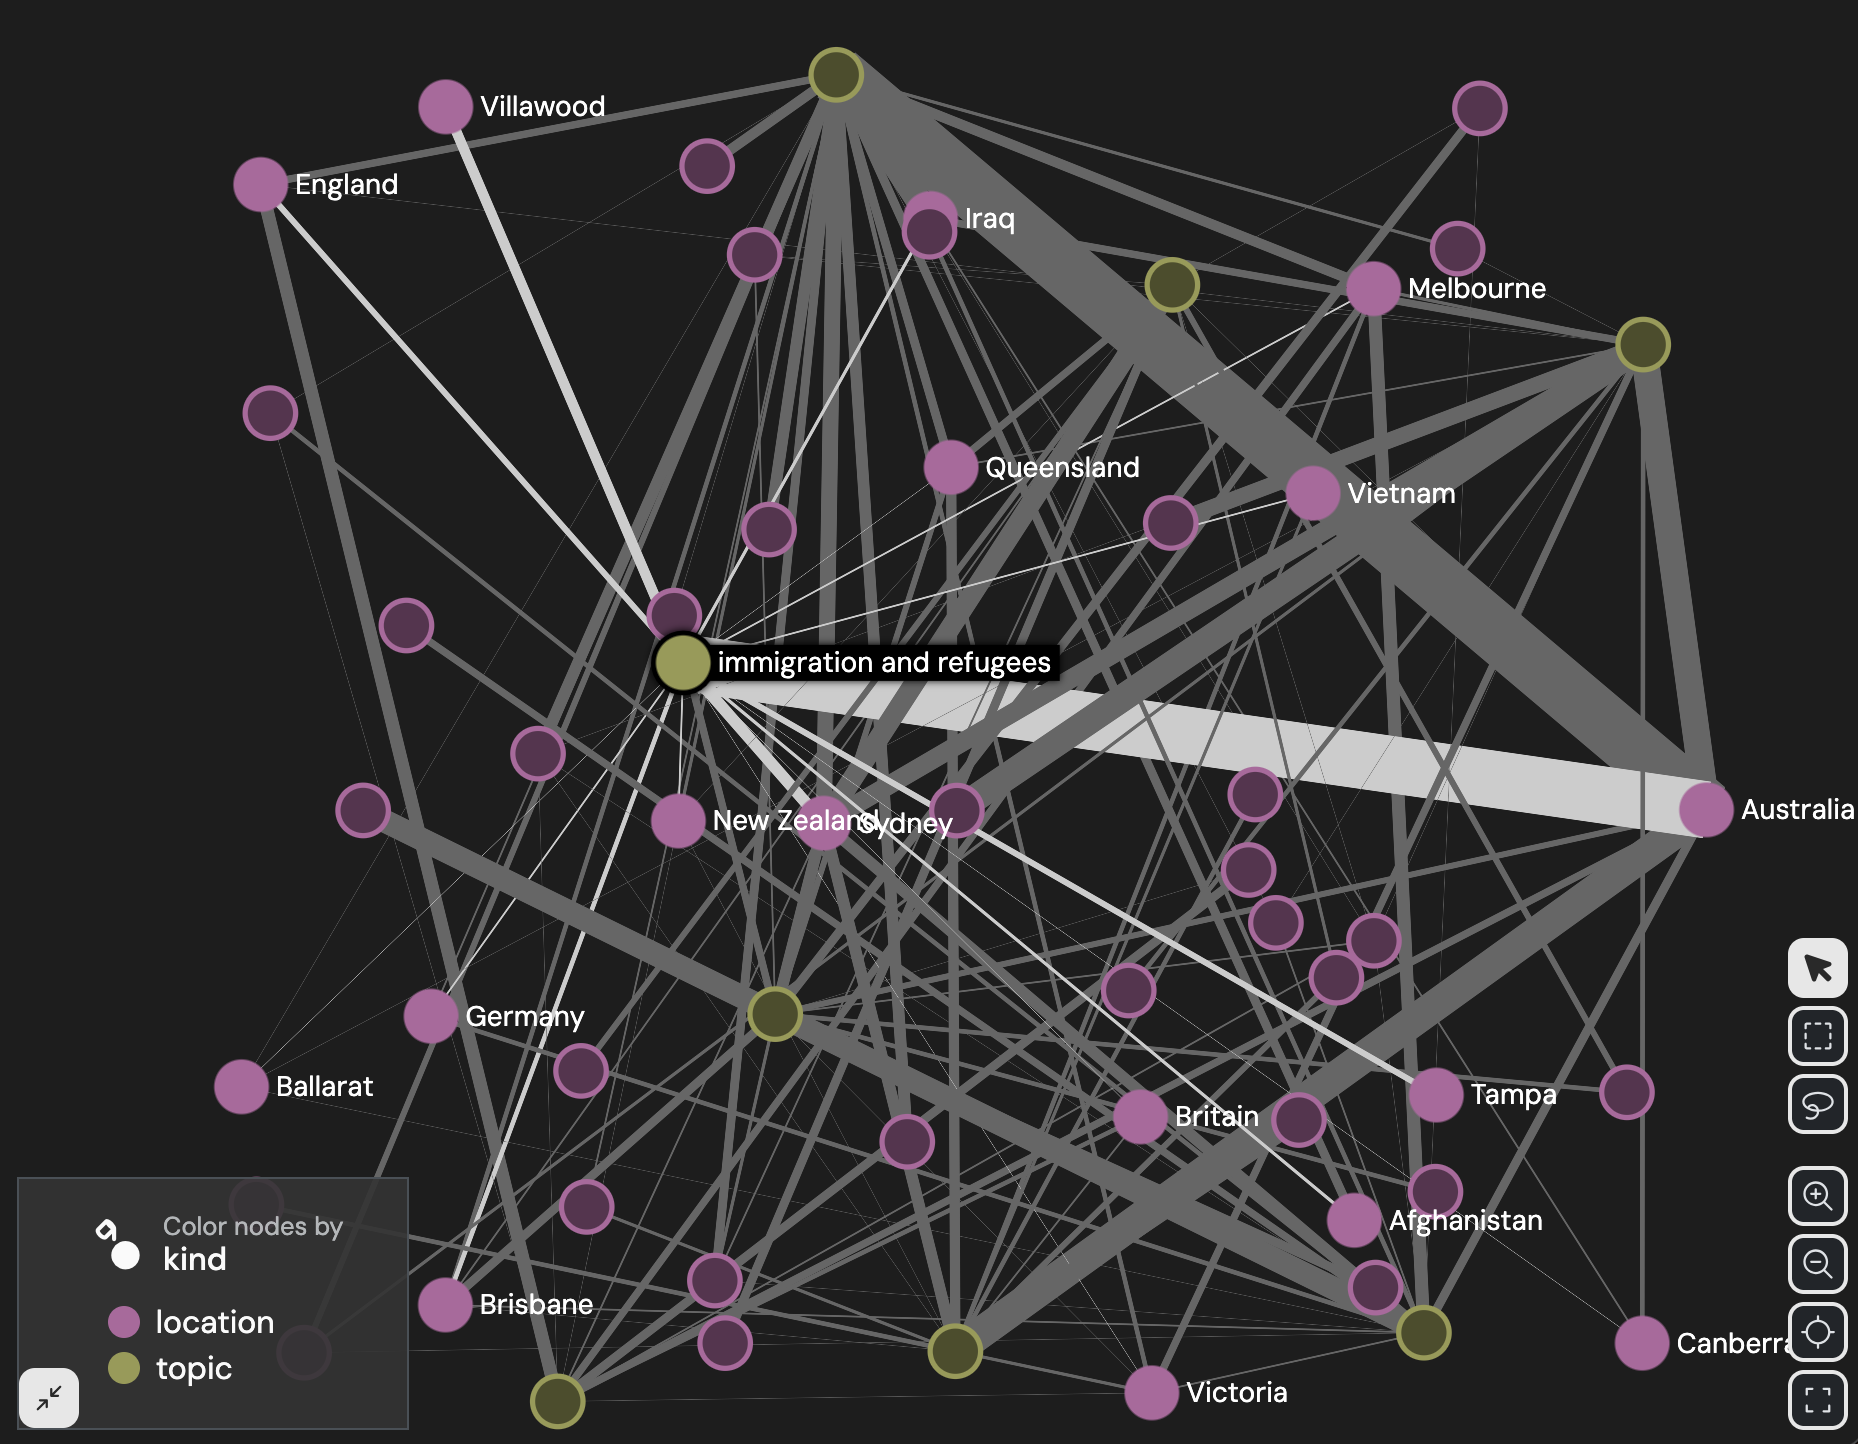

## 11. Public vs Commercial Radio

Derive two new dimensions for each recording:

- station_type: `public` (ABC: NAT, ABCe, ABCne) or `commercial` (COMe, COMne)
- region: `national`, `eastern`, or `south-west`

Then map the `recording_topic` assignments from Section 10 (keyed by file IDs like `'NAT6-plain.txt'`) back to the same recording-ID scheme used throughout.

The `station_type` and `region` values are not stored as explicit fields in the RO-Crate. They are derived from the recording ID prefixes (`Nat`, `ABCe`, `ABCne`, `COMe`, `COMne`), which encode the collection codes defined in the corpus description on the [LDaCA listing](https://data.ldaca.edu.au/collection?id=doi%3A10.25949%2F24769434.v1&_crateId=doi%3A10.25949%2F24769434.v1): *"14 transcribed recordings of talkback from ABC National Radio (NAT), ABC Radio broadcasts to eastern Australia (ABCE), ABC Radio broadcasts to southern and western Australia (ABCNE); as well as 15 transcribed recordings of talkback radio from commercial stations broadcasting to eastern Australia (COME) and southern and western Australia (COMNE)."*

In [ ]:
def classify_station(name):
    normalised_name = name.upper()
    if normalised_name.startswith("NAT"):
        return "public", "national"
    if normalised_name.startswith("ABCNE"):
        return "public", "south-west"   # before ABCE
    if normalised_name.startswith("ABCE"):
        return "public", "eastern"
    if normalised_name.startswith("COMNE"):
        return "commercial", "south-west"   # before COME
    if normalised_name.startswith("COME"):
        return "commercial", "eastern"
    return "unknown", "unknown"


station_rows = []
for _, recording_row in recordings_df.iterrows():
    station_type, region = classify_station(recording_row["id"])
    station_rows.append(
        {
            "recording_id": recording_row["id"],
            "station_type": station_type,
            "region": region,
        }
    )
station_meta = pd.DataFrame(station_rows)

print("Recordings by station type:")
print(station_meta["station_type"].value_counts().to_string())
station_meta.head()


The topic labels are keyed by transcript file IDs, while `station_meta` is keyed by recording IDs. Check one conversion before mapping all topics back onto the recording table.


In [ ]:
recording_id_lookup = {
    recording_id.upper(): recording_id
    for recording_id in recordings_df["id"]
}

example_topic_file = next(iter(recording_topic))
example_recording_key = example_topic_file.replace("-plain.txt", "").upper()

example_topic_file, example_recording_key, recording_id_lookup.get(example_recording_key)


In [ ]:
topic_by_recording = {}
for file_id, topic in recording_topic.items():
    recording_key = file_id.replace("-plain.txt", "").upper()
    recording_id = recording_id_lookup.get(recording_key)
    if recording_id:
        topic_by_recording[recording_id] = topic

station_meta["topic"] = station_meta["recording_id"].map(topic_by_recording)
station_meta


Join `utterances_df` (8,950 rows with role/sex/sentiment, from Sections 7–8) with `station_meta` on recording ID so every utterance inherits its recording's topic, station type, and region. 

In [ ]:
master_df = utterances_df.merge(
    station_meta, left_on="recording", right_on="recording_id"
)

print(f"{len(master_df):,} utterances across {master_df['recording'].nunique()} recordings")
print()
print(master_df.groupby("station_type")[["recording"]].nunique().rename(columns={"recording": "recordings"}))
master_df.head()

Which topics come up more in ABC vs commercial talkback? Each recording is counted once under its assigned topic.

In [ ]:
topic_counts = (
    station_meta.groupby(["topic", "station_type"])
    .size()
    .reset_index(name="count")
)

fig = px.bar(
    topic_counts,
    x="topic",
    y="count",
    color="station_type",
    barmode="group",
    title="Topic distribution: public vs commercial (recordings)",
    color_discrete_map={"public": "#1f77b4", "commercial": "#ff7f0e"},
    labels={
        "topic": "Topic",
        "count": "Number of recordings",
        "station_type": "Broadcaster type",
    },
)
fig.update_xaxes(tickangle=30)
fig.update_layout(legend_title_text="Broadcaster type")
fig.show()

Does the same topic attract more negative or positive speech on ABC vs commercial radio? Aggregate at the utterance level. Then plot mean sentiment with standard error bars and a heatmap summary.

In [ ]:
topic_sent = (
    master_df.groupby(["topic", "station_type"])["sentiment"]
    .agg(mean="mean", sem=lambda x: x.sem())
    .reset_index()
)

# Heatmap
heatmap_data = topic_sent.pivot(index="topic", columns="station_type", values="mean").round(3)
fig_heat = px.imshow(
    heatmap_data,
    color_continuous_scale="RdYlGn",
    color_continuous_midpoint=0,
    title="Mean utterance sentiment by topic and broadcaster type",
    labels={"color": "Mean sentiment"},
    text_auto=True,
)
fig_heat.update_layout(height=500)
fig_heat.show()

# Bar chart with error bars
fig_bar = px.bar(
    topic_sent,
    x="topic",
    y="mean",
    color="station_type",
    error_y="sem",
    barmode="group",
    title="Mean utterance sentiment by topic and broadcaster type (±1 SE)",
    color_discrete_map={"public": "#1f77b4", "commercial": "#ff7f0e"},
    labels={"mean": "Mean sentiment", "topic": "Topic", "station_type": "Broadcaster type"},
)
fig_bar.update_xaxes(tickangle=30)
fig_bar.update_layout(legend_title_text="Broadcaster type")
fig_bar.show()

## Next steps

- The people-and-recordings network used `expand()` and `visualise()`; see
  [Visualising a collection](../tutorials/visualising-a-collection.md) to colour by other
  properties or pull out ego-networks.
- Every table here came from `entity_records()`; the
  [From Graph to DataFrame](../tutorials/from-graph-to-dataframe.md) tutorial covers exporting
  these to CSV and joining them onto other analysis.
- The semantic index built in Section 6 also powers `chunk_records()` for RAG-style retrieval;
  swap in your own queries to explore the corpus.
